# Modelos contínuos

<hr>

### Distribuição uniforme

**O que é:** Atribui a mesma densidade de probabilidade a todos os pontos dentro de um intervalo [a,b]

**Quando usar:** Quando não há razão para acreditar que um valor no intervalo seja mais provável que outro, como o tempo de espera por um transporte com horário fixo

**Formato em sino:**  
Curva simétrica com maior concentração no centro

**Simetria:**  
Lado esquerdo e direito são iguais

**Média = Mediana = Moda:**  
Todas coincidem no centro da distribuição

**Parâmetros:**  
- μ (média): posição da curva  
- σ (desvio padrão): dispersão

**Regra empírica:**  
- ~68% dos dados em ±1σ  
- ~95% em ±2σ  
- ~99,7% em ±3σ  

**Caudas:**  
Se estendem infinitamente, sem tocar o eixo

**Exemplo:** O tempo que uma pessoa espera por um ônibus em um terminal, medido em minutos, é uniformemente distribuído em $[0,15]$.  

a) Calculale a probabilidade de que uma pessoa espere menos do que 12,5 minutos pelo ônibus.

In [ ]:
import numpy as np
np.random.seed(100)
ns = 100 # número de simulações
a = 0; b = 15 # parâmetros da distribuição uniforme
t = 12.5 # tempo de espera
sucesso = 0
for i in range(ns):
    if(np.random.uniform(a,b) <= t):
        # se o tempo for menor do que t
        sucesso = sucesso + 1
print("P(X < %1.1f) = " % (t), sucesso/ns)

P(X < 12.5) =  0.85


b) Em média, quanto tempo uma pessoa espera no terminal? Calcule também o desvio padrão.

In [ ]:
import numpy as np
np.random.seed(100)
ns = 100 #número de simulações
a = 0; b = 15 # parâmetros da distribuição uniforme
t = []
for i in range(ns):
    ti = np.random.uniform(a,b)
    t.append(ti)
print("E[X]=", np.mean(t))
print("std(X)=", np.std(t))

E[X]= 7.085501875788817
std(X)= 4.338424196729057


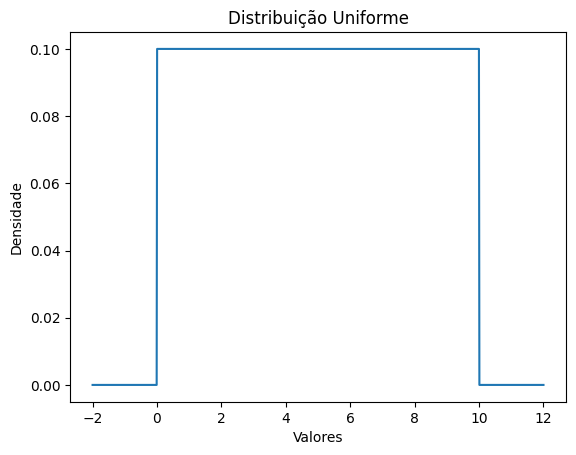

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# parâmetros (intervalo)
a = 0   # início
b = 10  # fim

# eixo x
x = np.linspace(a - 2, b + 2, 1000)

# densidade
y = uniform.pdf(x, loc=a, scale=b - a)

# gráfico
plt.figure()
plt.plot(x, y)
plt.title("Distribuição Uniforme")
plt.xlabel("Valores")
plt.ylabel("Densidade")

plt.show()

### Distribuição normal

**O que é:** Uma distribuição em forma de sino, simétrica em relação à média (μ)

**Quando usar:** É o modelo mais comum na natureza e estatística, aplicado a alturas, pesos, erros de medição e fenômenos que resultam da soma de muitos efeitos independentes

**Formato:**  
Curva em sino (bell-shaped), com maior concentração no centro

**Simetria:**  
Distribuição simétrica em torno da média

**Média = Mediana = Moda:**  
Medidas de tendência central coincidem

**Parâmetros:**  
- μ (média): posição da curva  
- σ (desvio padrão): dispersão (largura)

**Regra empírica:**  
- ~68% dos dados em ±1σ  
- ~95% em ±2σ  
- ~99,7% em ±3σ  

**Caudas:**  
Infinitas, aproximam-se do eixo sem tocá-lo

**Tipo:**  
Distribuição contínua (assume qualquer valor real)

**Padronização:**  
Pode ser transformada em normal padrão (μ=0, σ=1) via escore-z

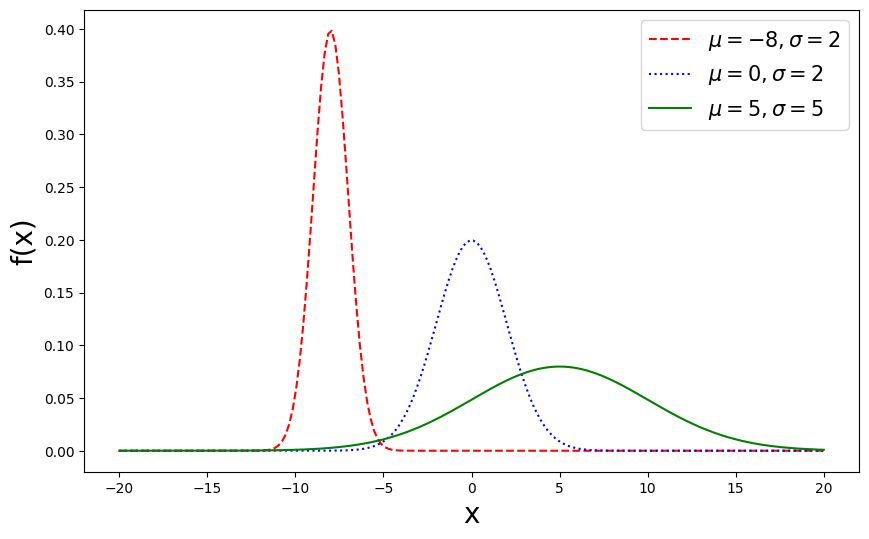

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math as math
from scipy.stats import norm

plt.figure(figsize=(10,6))
# define os valores de x
mean = -8
sigma = 1
x = np.linspace(-20,20,200)
pdf = norm.pdf(x,mean,sigma)
plt.plot(x,pdf , color = 'red',linestyle = 'dashed',
         label=r'$\mu=-8, \sigma =2$')

# define os valores de x
mean = 0
sigma = 2
pdf = norm.pdf(x,mean,sigma)
plt.plot(x,pdf , color = 'blue',linestyle = 'dotted',
         label=r'$\mu=0, \sigma =2$')

# define os valores de x
mean = 5
sigma = 5
pdf = norm.pdf(x,mean,sigma)
plt.plot(x,pdf , color = 'green',
         label=r'$\mu=5, \sigma =5$')

#Plotting the Results
plt.xlabel('x',fontsize = 20)
plt.ylabel('f(x)',fontsize = 20)
plt.legend(fontsize = 15)
plt.savefig('normal.svg')
plt.show()

Vamos mostrar a distribuição das alturas de homens e mulheres, coletadas por Francis Galton.<br>
https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/T0HSJ1

In [ ]:
import pandas as pd
import math as math
import matplotlib.pyplot as plt
from scipy.stats import norm

data = pd.read_csv('data/Galton.txt', sep="\t")
data.head(10)

,family,father,mother,gender,height,kids,male,female
0,1,78.5,67.0,M,73.2,4,1.0,0.0
1,1,78.5,67.0,F,69.2,4,0.0,1.0
2,1,78.5,67.0,F,69.0,4,0.0,1.0
3,1,78.5,67.0,F,69.0,4,0.0,1.0
4,2,75.5,66.5,M,73.5,4,1.0,0.0
5,2,75.5,66.5,M,72.5,4,1.0,0.0
6,2,75.5,66.5,F,65.5,4,0.0,1.0
7,2,75.5,66.5,F,65.5,4,0.0,1.0
8,3,75.0,64.0,M,71.0,2,1.0,0.0
9,3,75.0,64.0,F,68.0,2,0.0,1.0


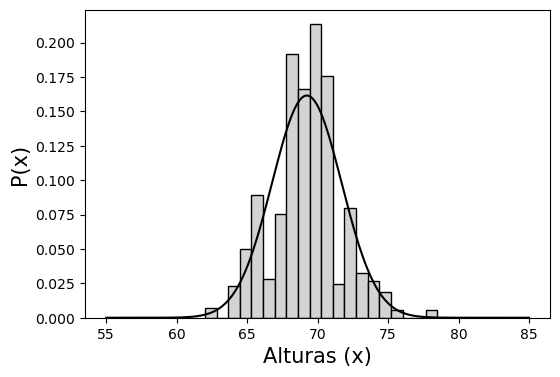

In [ ]:
x = data['father']
plt.figure(figsize=(6,4))
plt.hist(x, bins=20, color = 'lightgray', histtype='bar', ec='black', density = 'True')

#curva teórica
mean = np.mean(x)
sigma = np.std(x)
xn = np.linspace(55,85,200)
# Distribuicao teorica
pdf = norm.pdf(xn,mean,sigma)
plt.plot(xn,pdf , color = 'black')
plt.xlabel('Alturas (x)', fontsize = 15)
plt.ylabel('P(x)', fontsize = 15)
plt.savefig('galton-data.svg')
plt.show(True)

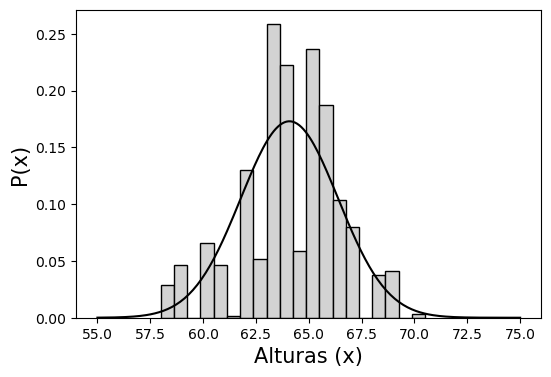

In [ ]:
x = data['mother']
plt.figure(figsize=(6,4))
plt.hist(x, bins=20, color = 'lightgray', histtype='bar', ec='black', density = 'True')

#curva teórica
mean = np.mean(x)
sigma = np.std(x)
xn = np.linspace(55,75,200)
# Distribuicao teorica
pdf = norm.pdf(xn,mean,sigma)
plt.plot(xn,pdf , color = 'black')
plt.xlabel('Alturas (x)', fontsize = 15)
plt.ylabel('P(x)', fontsize = 15)
plt.savefig('galton-data.svg')
plt.show(True)

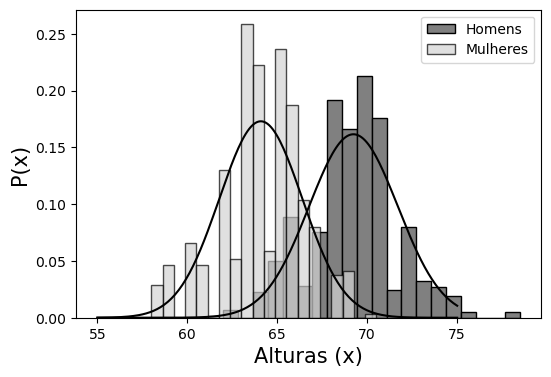

In [ ]:
plt.figure(figsize=(6,4))
x = data['father']
plt.hist(x, bins=20, color = 'gray', histtype='bar', ec='black', density = 'True', label='Homens')
#curva teórica
mx = np.mean(x)
sx = np.std(x)
xn = np.linspace(55,75,200)
pdfx = norm.pdf(xn,mx,sx)
plt.plot(xn,pdfx, color = 'black')

y = data['mother']
plt.hist(y, bins=20, color = 'lightgray', histtype='bar', ec='black',alpha=0.7, density = 'True', label='Mulheres')
# Distribuicao teorica: mulheres
my = np.mean(y)
sy = np.std(y)
pdfy = norm.pdf(xn,my,sy)
plt.plot(xn,pdfy, color = 'black')
plt.xlabel('Alturas (x)', fontsize = 15)
plt.ylabel('P(x)', fontsize = 15)
plt.legend(fontsize = 10)
plt.savefig('galton-data.svg')
plt.show(True)

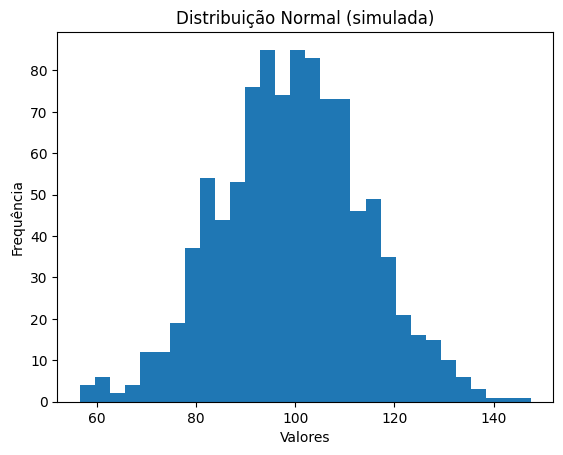

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Gerando dados normais
data = np.random.normal(loc=100, scale=15, size=1000)

# Estatísticas
mean = np.mean(data)
std = np.std(data)

mean, std

plt.figure()
plt.hist(data, bins=30)
plt.title("Distribuição Normal (simulada)")
plt.xlabel("Valores")
plt.ylabel("Frequência")

plt.show()

**Cálculo do escore-z**

In [2]:
# Escolhendo um valor
x = 130

z = (x - mean) / std

print(f"Escore-z de {x}: {z:.2f}")

Escore-z de 130: 2.10


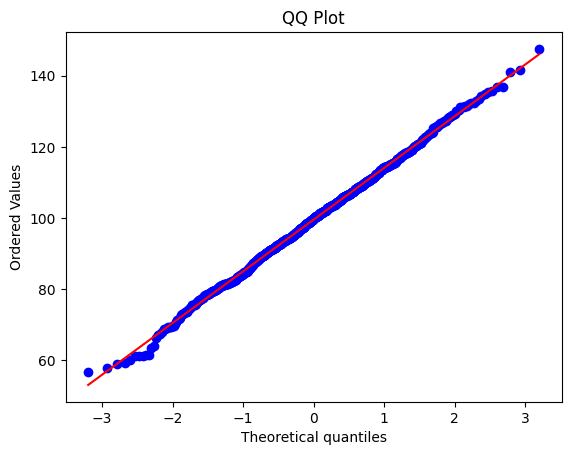

In [3]:
import scipy.stats as stats

stats.probplot(data, dist="norm", plot=plt)

plt.title("QQ Plot")
plt.show()

**Insight**

Se os pontos do gráfico QQ seguem aproximadamente uma linha reta, os dados são aproximadamente normais.

A distribuição normal é fundamental para diversas técnicas estatísticas e modelos de machine learning.

Podemos resolver alguns exemplos para verificar algumas aplicações dessa distribuição.

**Exemplo**: Se $X \sim  \mathcal{N}(\mu=165,\,\sigma^{2}=9)$, calcule $P(X<162)$.

In [ ]:
import scipy.stats as st

media = 165
dp = 3
z = (162-media)/dp
print('Z:', z)
print('P(X < 162) = ', st.norm.cdf(z))

Z: -1.0
P(X < 162) =  0.15865525393145707


**Exemplo**: Se $X \sim  \mathcal{N}(\mu=10,\,\sigma^{2}=4)$, calcule $P(X>13)$.

In [ ]:
import scipy.stats as st

media = 10
dp = 2
z = (13-media)/dp
print('Z:', z)
print('P(X > 13)=', 1-st.norm.cdf(z))

Z: 1.5
P(X > 13)= 0.06680720126885809


**Exemplo**: Se $X \sim \mathcal{N}(\mu=5,\sigma^2=4)$, calcule $P(4 \leq X \leq 6)$.

In [ ]:
import scipy.stats as st
media = 5
dp = 2
z1 = (4-media)/dp
z2 = (6-media)/dp
print('z1=',z1,'z2=',z2)
print('P(4 < X < 6)=', st.norm.cdf(z2)- st.norm.cdf(z1))

z1= -0.5 z2= 0.5
P(4 < X < 6)= 0.38292492254802624


**Exemplo:** O peso médio de 500 estudantes do sexo masculino de uma determinada universidade é 70 Kg e o desvio padrão é 5 Kg. Admitindo que os pesos são normalmente distribuídos, de forma aproximada, determine a percentagem de estudantes que pesam entre 65 Kg e 75 Kg.

$$
\begin{aligned}
P(65\leq X \leq 75) &=  P\left(\frac{65-\mu}{\sigma} \leq \frac{X-\mu}{\sigma} \leq \frac{75 - \mu}{\sigma} \right) = \\
& =  P\left(\frac{65-70}{5} \leq Z \leq \frac{75 -70}{5} \right) =  \\
& = P(Z \leq 1) - P(Z \leq -1) = 0,68.
\end{aligned}
$$

In [ ]:
import scipy.stats as st
media = 70
dp = 5
z1 = (65-media)/dp
z2 = (75 -media)/dp
print('z1=',z1,'z2=',z2)
print('Probabilidade teórica:',st.norm.cdf(z2)-st.norm.cdf(z1))

z1= -1.0 z2= 1.0
Probabilidade teórica: 0.6826894921370859


Simulando:

In [ ]:
import numpy as np
np.random.seed(100)
media = 70
dp = 5
n = 100
# gera n valores de uma distribuição normal
X = np.random.normal(media, dp, n)
m = 0 # número casos no intervalo
for x in X:
    # verifica se x está no intervalo
    if (x > 65 and x < 75):
        m = m + 1
print('P(65< X < 75)=', m/n)

P(65< X < 75)= 0.67


b) mais do que 80 Kg.

In [ ]:
z1 = (80-media)/dp
p = 1-st.norm.cdf(z1)
print('Probabilidade teórica:',p)

Probabilidade teórica: 0.02275013194817921


In [ ]:
media = 70
dp = 5
n = 100
X = np.random.normal(media, dp, n)
m = 0 # número de sucessos
for x in X:
    if x > 80:
        m = m + 1
print('Probabilidade (simulação):', m/n)

Probabilidade (simulação): 0.03


**Exemplo:** Uma máquina de bebidas está regulada de modo a servir uma média de 150ml por copo. Se a quantidade servida por copo seguir uma distribuição normal com desvio padrão de 20 ml, determine a percentagem de copos que conterão mais de 175ml de bebida.

$$
P(X \geq 175) = P\left( \frac{X-\mu}{\sigma}\geq \frac{175-\mu}{\sigma}\right) = P\left( Z \geq \frac{175-\mu}{\sigma}\right) = 1 - P\left( Z < \frac{175-\mu}{\sigma}\right)
$$

In [ ]:
media = 150
dp = 20
z = (175-media)/dp
print((1-st.norm.cdf(z))*100,'%')

10.564977366685536 %


Comparando a curva teórica com simulações:

Text(0, 0.5, 'Probability Density')

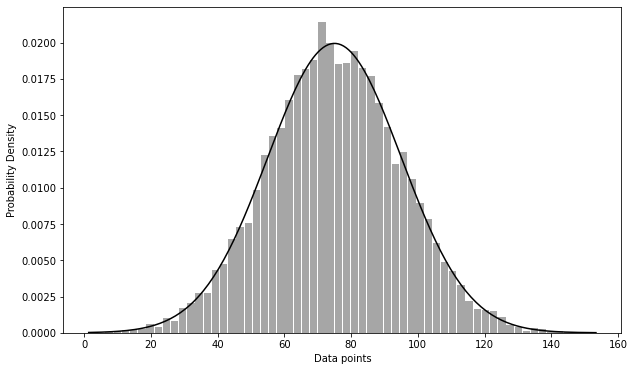

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math as math

# funcao que mostra a distribuicao teorica
def normal_dist(x , mean , sigma):
    prob_density = (1/(sigma*(math.sqrt(2*np.pi))))*np.exp(-0.5*((x-mean)/sigma)**2)
    return prob_density

#Calculate mean and Standard deviation.
mean = 75
sigma = 20
n = 10000
X = np.random.normal(mean, sigma, n)
plt.figure(figsize=(10,6))
Pk, bins, ignored = plt.hist(X, bins='auto', density=True, color='gray',alpha=0.7,
                                rwidth=0.9)

# define os valores de x
x = np.linspace(np.min(X),np.max(X),200)
# Distribuicao teorica
pdf = normal_dist(x,mean,sigma)

#Plotting the Results
plt.plot(x,pdf , color = 'black')
plt.xlabel('Data points')
plt.ylabel('Probability Density')

#### Distribuição Exponencial

**O que é:** Caracterizada por uma taxa de ocorrência λ e pela propriedade de ausência de memória

**Quando usar:** Para modelar o tempo entre eventos consecutivos, como o tempo entre falhas de um equipamento ou a chegada de clientes em uma fila

Utiliza o mesmo parâmetro λ (lambda) da distribuição Poisson.

Modela o tempo entre eventos, como:
- visitas a um site  
- chegada de carros em um pedágio  

Também é usada em:
- engenharia (tempo até falha)  
- gestão de processos (tempo por chamada de serviço)

(Exponencial = caso especial da Gama)

Poisson → número de eventos

Exponencial → tempo entre eventos

**Exemplo: tempo entre eventos**

Suponha que, em média, ocorrem 2 eventos por minuto (λ = 2).

Podemos modelar o tempo entre eventos usando a distribuição exponencial.

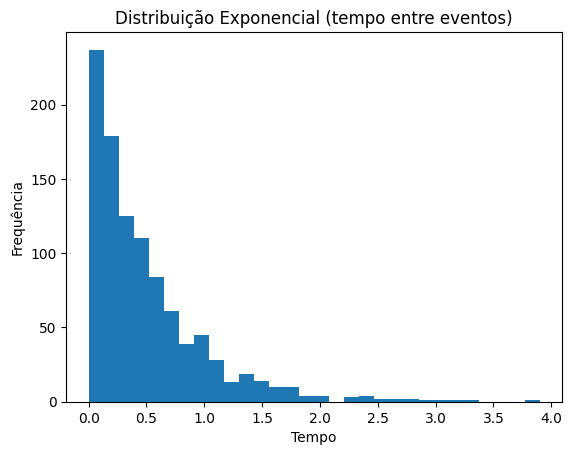

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# taxa (lambda)
lambda_ = 2

# escala = 1 / lambda
scale = 1 / lambda_

# simulando tempos entre eventos
data = np.random.exponential(scale=scale, size=1000)

# visualização
plt.figure()
plt.hist(data, bins=30)
plt.title("Distribuição Exponencial (tempo entre eventos)")
plt.xlabel("Tempo")
plt.ylabel("Frequência")

plt.show()

**Insight**

A maioria dos eventos ocorre em intervalos curtos de tempo, mas existe uma cauda longa, indicando que intervalos maiores também podem acontecer, embora com menor frequência.

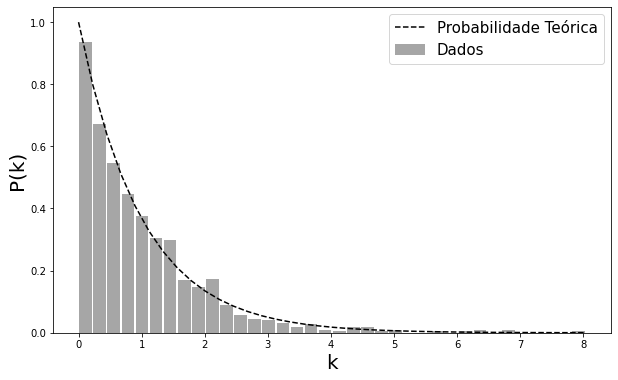

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

mean = 1 # média
n = 1000 # número de simulações
X = np.random.exponential(mean, n)
count, bins, ignored = plt.hist(X, 'auto', density=True,
                                color='gray',alpha=0.7, rwidth=0.9, label='Dados')
plt.plot(bins, (1/mean)*np.exp(-bins/mean),
         linestyle = 'dashed', color='black', label='Probabilidade Teórica')
plt.legend(fontsize = 15)
plt.xlabel('k', fontsize = 20)
plt.ylabel('P(k)',fontsize = 20)
plt.show()

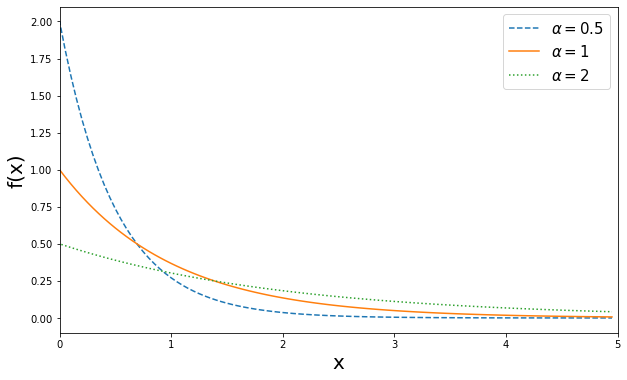

In [ ]:
from scipy.stats import expon
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-1, 5, 0.05)

plt.figure(figsize=(10,6))
lines = ['dashed','solid','dotted']
alphas = [0.5,1,2]
aux = 0
for alpha in alphas:
    y = expon.pdf(x,scale=alpha)
    plt.plot(x, y,linestyle=lines[aux], label=r'$\alpha=$'+str(alpha))
    aux = aux + 1
plt.xlabel('x', fontsize = 20)
plt.ylabel('f(x)',fontsize = 20)
plt.legend(fontsize = 15)
plt.xlim(0,5)
plt.savefig('exp.svg')
plt.show(True)

**Exemplo** Suponha que chegamos a um ponto de ônibus e notamos que o último veículo passo há 5 minutos. Se os ônibus chegam em média a cada 20 minutos, qual é a probabilidade de que tenhamos que esperar mais 15 minutos pela chegada do próximo ônibus?

In [ ]:
import numpy as np
E = 20
alpha = 1/E
x = 15
p = np.exp(-alpha*x)
print('P(X>15|X>5)=P(X>10)=', p)

P(X>15|X>5)=P(X>10)= 0.4723665527410147


**Exemplo:** Estudantes chegam a uma festa a uma taxa de 30 estudantes por hora, passando pela portaria do evento.  Qual é a probabilidade de que a portaria esperará pela chegada de um estudante por um tempo maior do que três minutos?


In [ ]:
import numpy as np
np.random.seed(100)

lbd = 0.5 # taxa
x = 3 # tempo de espera
ns = 100 # número de simulações
m = 0 # número de sucessos
for s in range(0,ns):
    t = np.random.exponential(1/lbd)
    if(t > x):
        m = m + 1
print('P(X > %d) = %s' % (x, m/ns))

P(X > 3) = 0.21


#### Distribuição Gama

**O que é:** Generalização da exponencial. Se α for inteiro, representa a soma de α variáveis exponenciais independentes

**Quando usar:** Em situações onde um sistema depende da ocorrência de múltiplos eventos sucessivos para falhar ou ser concluído, como o tempo total de vida de um sistema com componentes reserva

Distribuição contínua usada para modelar tempo até múltiplos eventos.

Generaliza a distribuição exponencial.

Aplicações:
- tempo até falha  
- tempo até ocorrência de vários eventos  

Parâmetros:
- k (forma)  
- θ (escala)## Distribuição gama

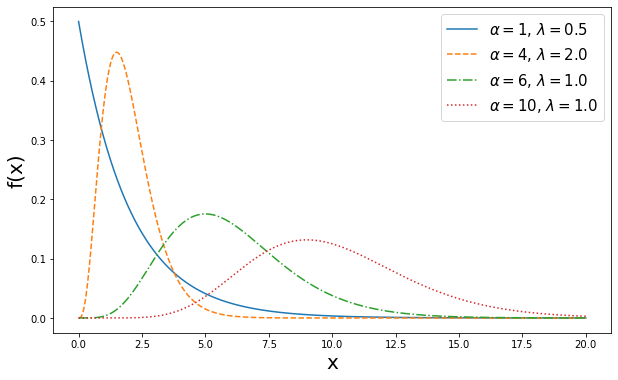

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

plt.figure(figsize=(10,6))
styl_list=['-','--','-.',':']
# parâmetros da distribuição
parameters = [[1,0.5],[4,2],[6,1],[10,1]]
x = np.linspace(0,20, 1000)
aux = 0
for i in parameters:
    alpha, lbd = i
    shape = alpha
    scale = 1/lbd
    dist = gamma.pdf(x, a=shape, scale=scale)
    plt.plot(x, dist, label=r'$\alpha=$'+str(shape)+r', $\lambda=$'+str(1/scale), ls=styl_list[aux])
    aux = aux + 1
plt.xlabel('x', fontsize= 20)
plt.ylabel('f(x)', fontsize= 20)
plt.legend(fontsize = 15)
plt.savefig('gama.svg')
plt.show()

#### Distribuição Beta

**O que é:** Definida no intervalo limitado

**Quando usar:** Ideal para modelar proporções, taxas ou probabilidades, como a taxa de conversão de uma campanha de marketing

Distribuição contínua definida no intervalo [0, 1].

Usada para modelar probabilidades e proporções, como:
- taxa de conversão  
- probabilidade de sucesso  

Parâmetros:
- α (alpha) e β (beta) controlam o formato da distribuição

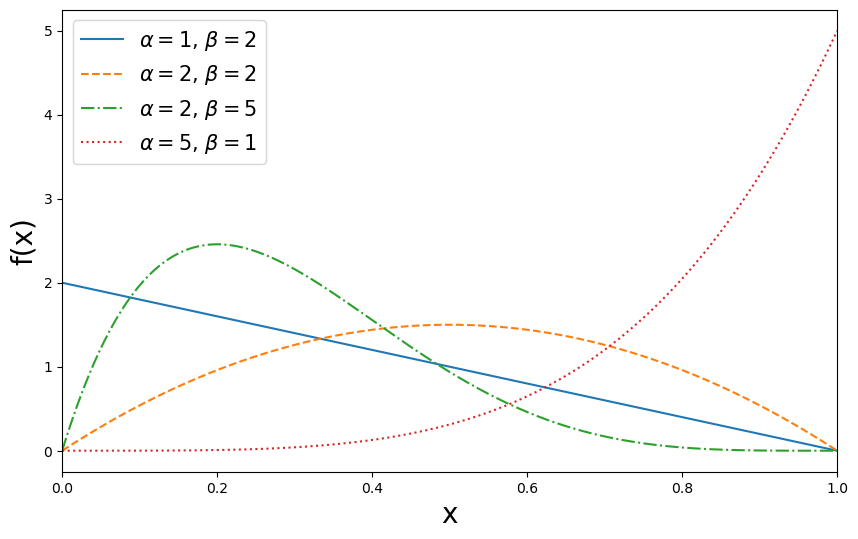

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

plt.figure(figsize=(10,6))
styl_list=['-','--','-.',':']
plt.xlim(0, 1)
# parâmetros da distribuição
parameters = [[1,2],[2,2],[2,5],[5,1]]
x = np.linspace(0,1, 1000)
aux = 0
for i in parameters:
    a,b = i
    plt.plot(x, beta.pdf(x, a, b),
             label=r'$\alpha=$'+str(a)+r', $\beta=$'+str(b),
             ls=styl_list[aux])
    aux = aux + 1

plt.xlabel('x', fontsize= 20)
plt.ylabel('f(x)', fontsize= 20)
plt.legend(fontsize = 15)
plt.savefig('beta.svg')
plt.show()

Para $\alpha=\beta$:

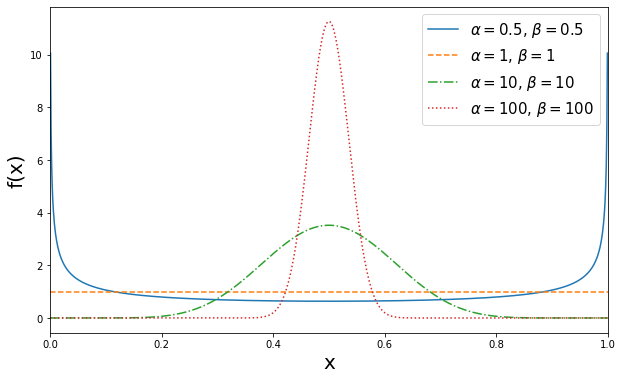

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

plt.figure(figsize=(10,6))
styl_list=['-','--','-.',':']
plt.xlim(0, 1)
# parâmetros da distribuição
parameters = [[0.5,0.5],[1,1],[10,10],[100,100]]
x = np.linspace(0,1, 1000)
aux = 0
for i in parameters:
    a,b = i
    plt.plot(x, beta.pdf(x, a, b),
             label=r'$\alpha=$'+str(a)+r', $\beta=$'+str(b),
             ls=styl_list[aux])
    aux = aux + 1

plt.xlabel('x', fontsize= 20)
plt.ylabel('f(x)', fontsize= 20)
plt.legend(fontsize = 15)
plt.savefig('beta.svg')
plt.show()

#### Distribuição t-Student

**O que é:** Similar à normal, mas com caudas mais largas. Aproxima-se da normal conforme os graus de liberdade aumentam

**Quando usar:** Usada principalmente em inferência estatística quando o tamanho da amostra é pequeno e a variância populacional é desconhecida

**n:**  
Tamanho da amostra

**Graus de liberdade:**  
Parâmetro que ajusta a distribuição t conforme o tamanho da amostra, estatísticas e número de grupos

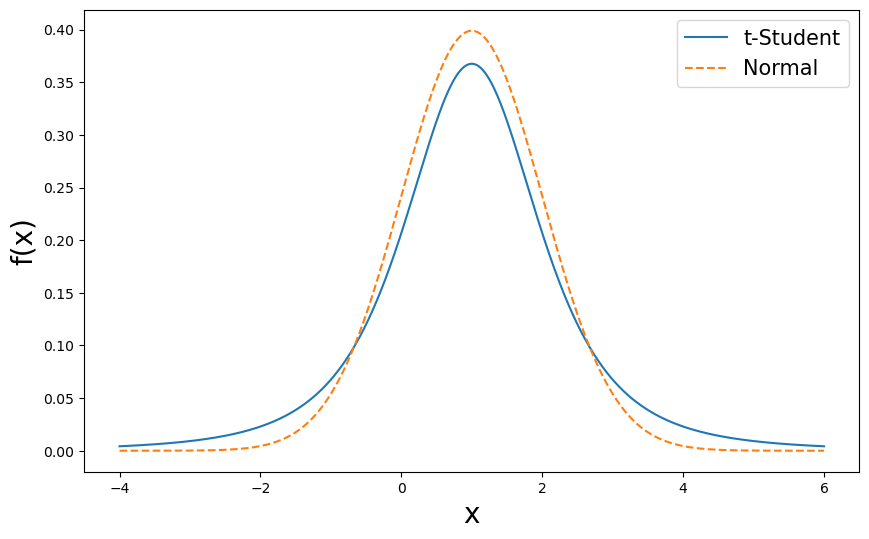

In [ ]:
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt
%matplotlib inline

gl = 3 # graus de liberdade
mean = 1 # média
std_dev = 1 # desvio padrão

x = np.linspace(-4, 6, 1000)
# dados da distribuição t de Student
dist_t = scipy.stats.t(df=gl, loc=mean, scale=std_dev)
y = dist_t.pdf(x)
# dados da distribuição normal
dist_normal = scipy.stats.norm(mean,std_dev)
yn = dist_normal.pdf(x)

# mostra os resultados
plt.figure(figsize=(10,6))
plt.plot(x,y, ls ='-', label = 't-Student')
plt.plot(x,yn, ls ='--', label = 'Normal')
plt.xlabel('x', fontsize= 20)
plt.ylabel('f(x)', fontsize= 20)
plt.legend(fontsize = 15)
plt.savefig('t.svg')
plt.show()

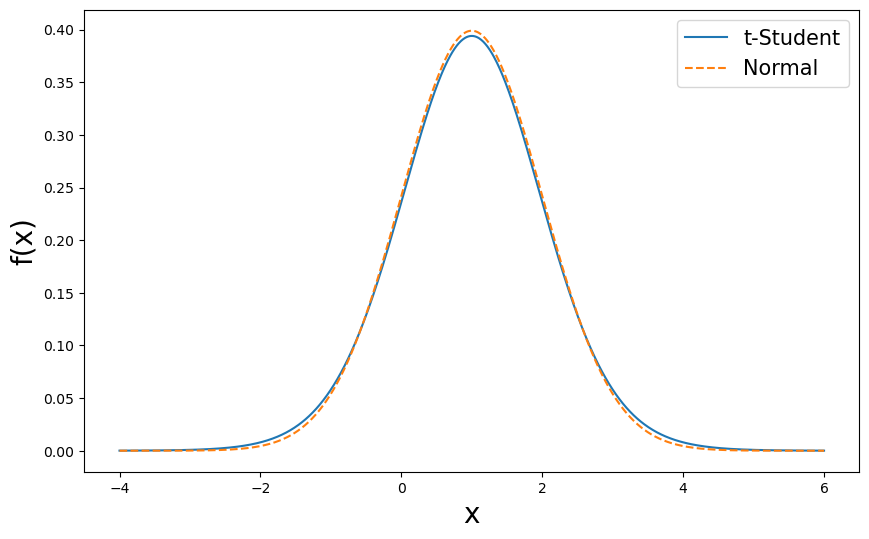

In [ ]:
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10,6))
df = 20
mean = 1
std_dev = 1

x = np.linspace(-4, 6, 1000)
dist_t = scipy.stats.t(df=df, loc=mean, scale=std_dev)
y = dist_t.pdf(x)
dist_normal = scipy.stats.norm(mean,std_dev)
yn = dist_normal.pdf(x)

plt.plot(x,y, ls ='-', label = 't-Student')
plt.plot(x,yn, ls ='--', label = 'Normal')
plt.xlabel('x', fontsize= 20)
plt.ylabel('f(x)', fontsize= 20)
plt.legend(fontsize = 15)
plt.savefig('t2.svg')
plt.show()

### Distribuição chi-quadrado

**O que é:** Soma dos quadrados de k variáveis normais padronizadas independentes

**Quando usar:** Frequentemente usada para avaliar a variabilidade de medições e em testes de hipóteses estatísticas

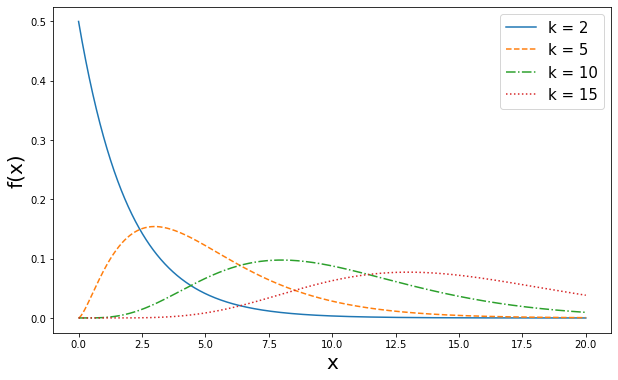

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

plt.figure(figsize=(10,6))
styl_list=['-','--','-.',':'] # list of basic linestyles

parameters = [2,5,10,15]
x = np.linspace(0,20, 1000)
aux = 0
for k in parameters:
    dist = chi2.pdf(x, df=k)
    plt.plot(x, dist, label=r'k = '+str(k), ls=styl_list[aux])
    aux = aux + 1

plt.xlabel('x', fontsize= 20)
plt.ylabel('f(x)', fontsize= 20)
plt.legend(fontsize = 15)
plt.savefig('chi2.svg')
plt.show()